<div style="padding:20px;color:white;margin:0;font-size:300%;text-align:center;display:fill;border-radius:60px;background-color:#0FD34D;overflow:hidden;font-weight:800">School Student Daily</div>

## <b><div style='padding:15px;background-color:#0FD34D;color:white;border-radius:40px;font-size:110%;text-align: center'>1  |  About Dataset</div></b>

Daily listing (counts) of students registered, present, absent and released by School DBN.

Each record includes the date, total enrollment, number of students absent, present, and released on that day. This structured data is pivotal for understanding daily attendance trends, student engagement, and the operational dynamics of the school environment over time.

From a data science perspective, this dataset is a treasure trove for analyzing educational trends, attendance patterns, and their correlations with academic performance and other socio-economic factors. Analyzing these patterns over time or across different schools can help in identifying critical issues such as chronic absenteeism, the effectiveness of attendance policies, and the impact of external factors on student attendance.

## <b><div style='padding:15px;background-color:#0FD34D;color:white;border-radius:40px;font-size:110%;text-align: center'>2  |  Importing Libraries</div></b>

In [ ]:
!pip uninstall prophet
!pip uninstall pystan
!pip install pystan==2.19.1.1
!pip install prophet

Found existing installation: prophet 1.1.7
Uninstalling prophet-1.1.7:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/prophet-1.1.7.dist-info/*
    /usr/local/lib/python3.12/dist-packages/prophet.libs/libtbb-ff323302.so.2
    /usr/local/lib/python3.12/dist-packages/prophet.libs/libtbbmalloc-4dcb68e3.so.2
    /usr/local/lib/python3.12/dist-packages/prophet/*
Proceed (Y/n)? Y
  Successfully uninstalled prophet-1.1.7
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.2/16.2 MB 54.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pystan
  Running setup.py clean for pystan
Failed to build pystan
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pystan)
   ━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## <b><div style='padding:15px;background-color:#0FD34D;color:white;border-radius:40px;font-size:110%;text-align: center'>3  |  Downloading Dataset</div></b>

In [ ]:
df = pd.read_csv('2018-2019_Daily_Attendance_20240429.csv')


In [ ]:
# Check first 5 lines

df.head()

,School DBN,Date,Enrolled,Absent,Present,Released
0,01M015,20180905,172,19,153,0
1,01M015,20180906,171,17,154,0
2,01M015,20180907,172,14,158,0
3,01M015,20180912,173,7,166,0
4,01M015,20180913,173,9,164,0


## <b><div style='padding:15px;background-color:#0FD34D;color:white;border-radius:40px;font-size:110%;text-align: center'>4  |  Inspecting and Cleaning Dataframe Structure</div></b>

In [ ]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (277153, 6)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
School DBN,object,0,0.0,0,1583,277153,NaN,NaN,NaN,NaN,01M015,01M015,01M015
Date,int64,0,0.0,0,185,277153,20180904.0,20190626.0,20186649.077827,4555.412537,20180905,20180906,20180907
Enrolled,int64,0,0.0,0,3102,277153,1.0,5955.0,596.98617,482.90966,172,171,172
Absent,int64,0,0.0,0,747,277153,0.0,2151.0,50.503538,54.329671,19,17,14
Present,int64,0,0.0,0,3727,277153,1.0,5847.0,544.499403,452.970313,153,154,158
Released,int64,0,0.0,0,482,277153,0.0,5904.0,1.983229,35.114511,0,0,0


<div class="alert alert-block alert-info" style="background-color:#CDFCDC;color:#0FD34D;border-color:black;width:80%;margin: auto;text-align: center;"><b>Comment:</b> No Missing, No Dups.</div>

In [ ]:
# Let's create the percentage of Absnet and percentage of Present columns.
df['%_Absnet'] = ((df['Absent'] / df['Enrolled']) *100).round(2)
df['%_Present'] = ((df['Present'] / df['Enrolled']) *100).round(2)
df.head(2)

,School DBN,Date,Enrolled,Absent,Present,Released,%_Absnet,%_Present
0,01M015,20180905,172,19,153,0,11.05,88.95
1,01M015,20180906,171,17,154,0,9.94,90.06


## <b><div style='padding:15px;background-color:#0FD34D;color:white;border-radius:40px;font-size:110%;text-align: center'>5  |  EDA</div></b>

### <b><span style='color:#DEB078'>5.1 |</span><span style='color:#0FD34D'> %_Absnet and %_Present</span></b>

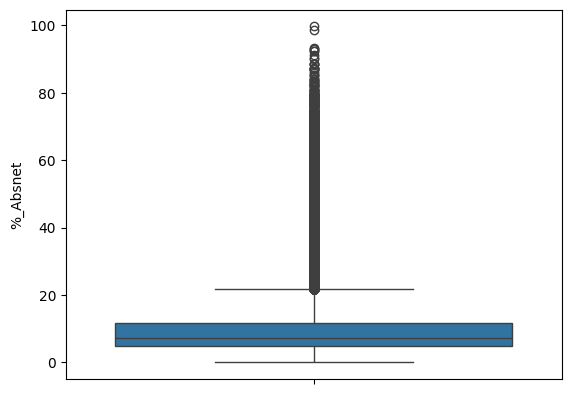

In [ ]:
sns.boxplot(y = '%_Absnet', data = df)
plt.show()

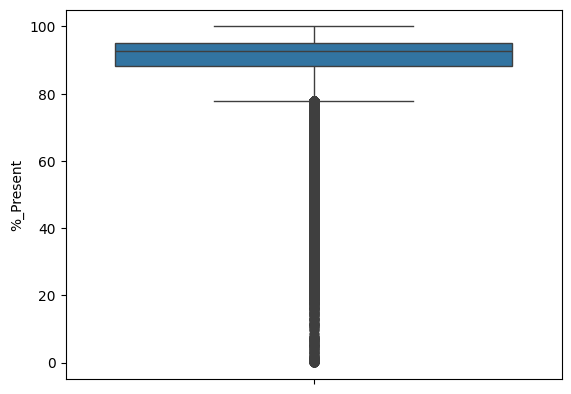

In [ ]:
sns.boxplot(y = '%_Present', data = df)
plt.show()

<div class="alert alert-block alert-info" style="background-color:#CDFCDC;color:#0FD34D;border-color:black;width:80%;margin: auto;text-align: center;"><b>Comment:</b> Although there are many outliers, we will not exclude them as I want them to be part of the EDA. We will deal with them later.</div>

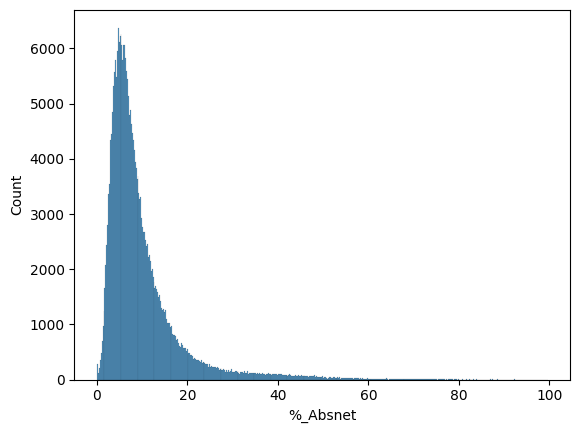

In [ ]:
sns.histplot(data=df, x="%_Absnet")
plt.show()

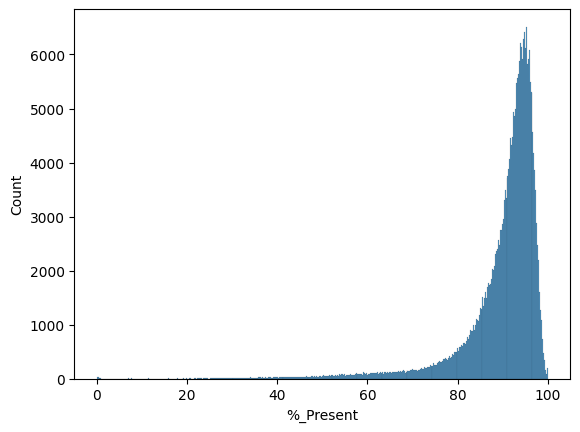

In [ ]:
sns.histplot(data=df, x="%_Present")
plt.show()

In [ ]:
# Convert 'Date' column to 'Datetime' type.
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

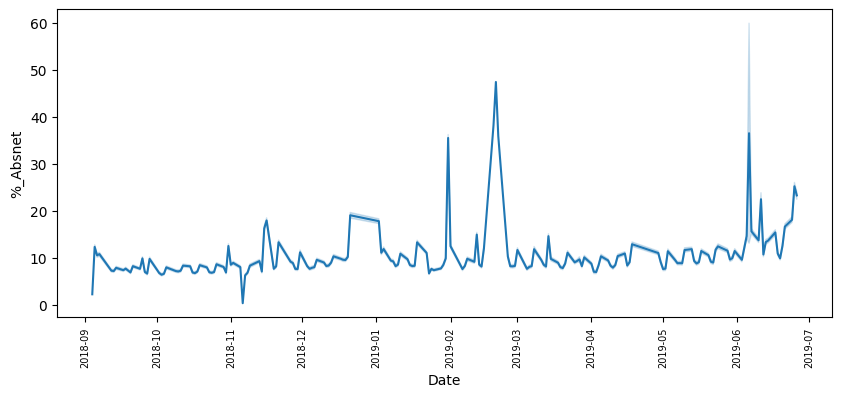

In [ ]:
# Let's see the time series of %_Absnet
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(data=df, x="Date", y="%_Absnet")
plt.xticks(rotation=90, fontsize = 7)

plt.show()

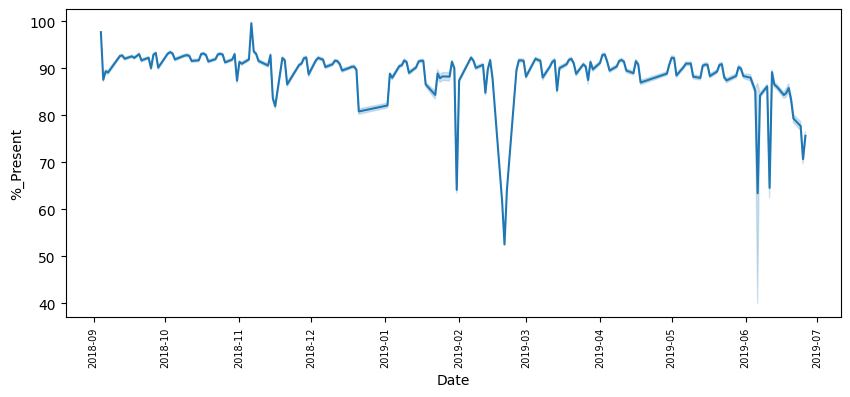

In [ ]:
# Let's see the time series of %_Present

fig, ax = plt.subplots(figsize=(10, 4)) # Used to change the chart size.

sns.lineplot(data=df, x="Date", y="%_Present")
plt.xticks(rotation=90, fontsize = 7)

plt.show()

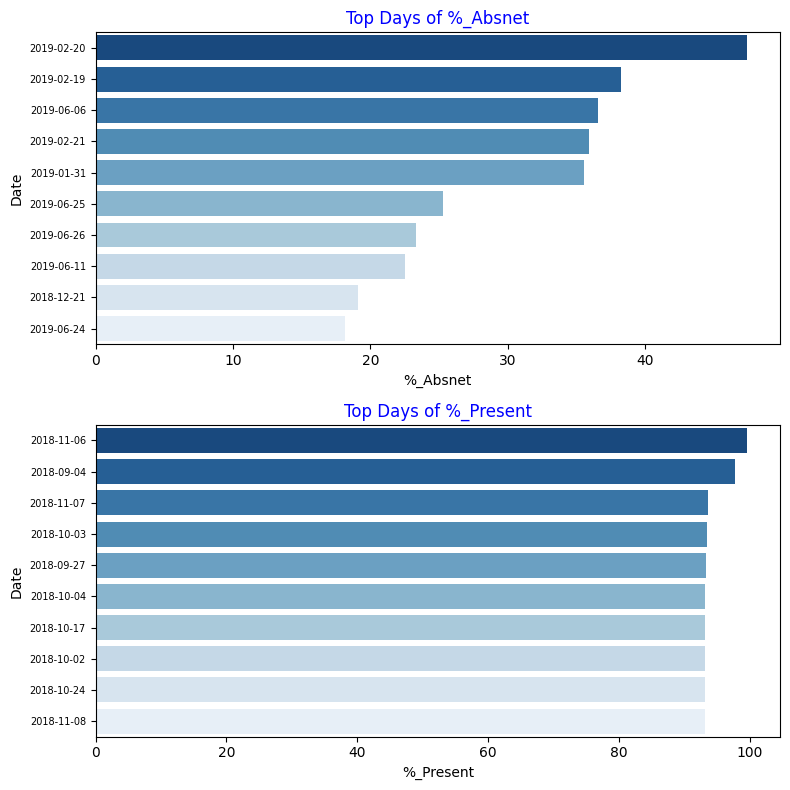

In [ ]:
# Top Days of %_Absnet and %_Present
cols = ['%_Absnet', '%_Present']
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

for ind, col in enumerate(cols):
    plt.subplot(2, 1, ind+1)
    df_top = df.groupby(['Date'])[[col]].mean().reset_index()
    df_top = df_top.sort_values(by=(col), ascending=False).head(10)

    sns.barplot(y=df_top["Date"], x=df_top[col], palette="Blues_r")
    plt.yticks(rotation=0, fontsize = 7)
    plt.title(f"Top Days of {col}", fontsize = 12, color = 'blue')

plt.tight_layout()

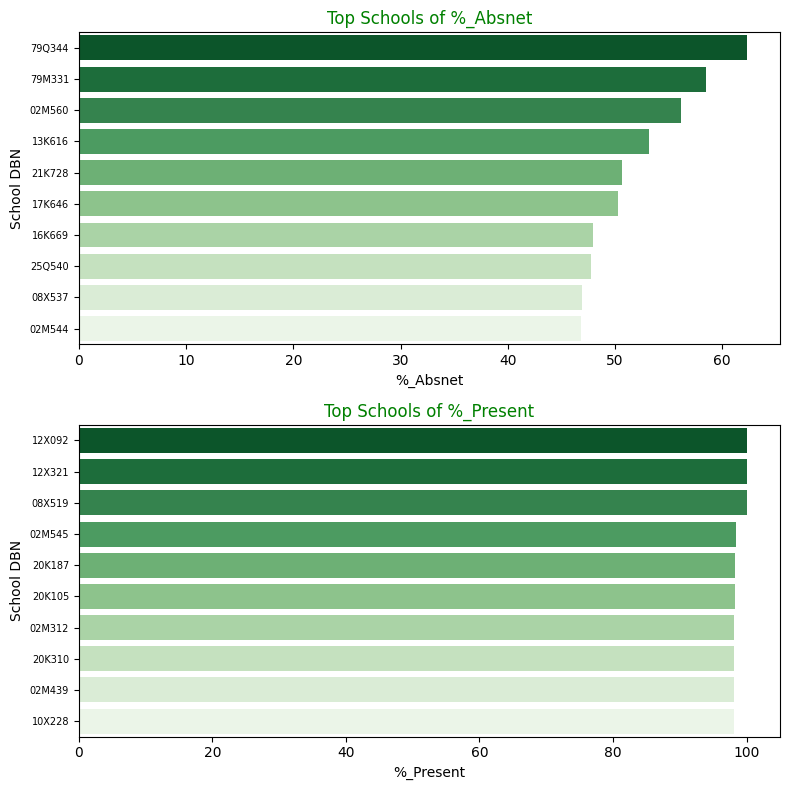

In [ ]:
# Top Schools of %_Absnet and %_Present
cols = ['%_Absnet', '%_Present']
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

for ind, col in enumerate(cols):
    plt.subplot(2, 1, ind+1)
    df_top = df.groupby(['School DBN'])[[col]].mean().reset_index()
    df_top = df_top.sort_values(by=(col), ascending=False).head(10)

    sns.barplot(y=df_top["School DBN"], x=df_top[col], palette="Greens_r")
    plt.yticks(rotation=0, fontsize = 7)
    plt.title(f"Top Schools of {col}", fontsize = 12, color = 'green')

plt.tight_layout()

### <b><span style='color:#DEB078'>5.2 |</span><span style='color:#0FD34D'> Comparison between two schools.</span></b>

In [ ]:
# Let's create a dataframe for the school with the highest number of absences.
df_79Q344 = df[df['School DBN'] == '79Q344']

# Let's create a dataframe for the school with the fourth lowest number of absences.
# We will not use the first 3 schools as they have little recorded data.
df_02M545 = df[df['School DBN'] == '02M545']


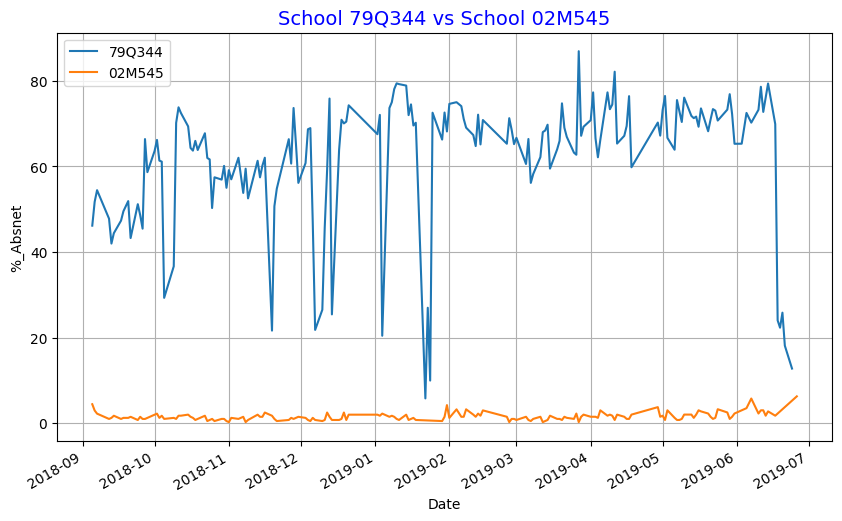

In [ ]:
# Now let's plot the '%_Absnet' from the 2 schools for comparison purposes.

# Groupby - Date
df_44 = df_79Q344.groupby('Date')['%_Absnet'].sum().reset_index()
df_45 = df_02M545.groupby('Date')['%_Absnet'].sum().reset_index()

# Rename columns
df_44.rename(columns = {'%_Absnet':'79Q344'}, inplace = True)
df_45.rename(columns = {'%_Absnet':'02M545'}, inplace = True)

# Concat datasets
df_both = pd.concat([df_44, df_45])

# Plot
df_both.plot(x="Date", y=['79Q344', '02M545'],
              kind="line", figsize=(10, 6))
plt.title("School 79Q344 vs School 02M545", fontsize = 14, color = 'blue')
plt.ylabel('%_Absnet', rotation=90, fontsize = 10)

plt.grid()
plt.show()

<div class="alert alert-block alert-info" style="background-color:#CDFCDC;color:#0FD34D;border-color:black;width:80%;margin: auto;text-align: center;"><b>Comment:</b> We can see that school 79Q344 has a very large number of %_Absnet, while school 02M545 has a low number of %_Absnet.</div>

## <b><div style='padding:15px;background-color:#0FD34D;color:white;border-radius:40px;font-size:110%;text-align: center'>6  |  Prophet</div></b>

In [ ]:
from prophet import Prophet

In [ ]:
# Create a dataframe with the average of %_Absnet for all schools.

df_mean = df.groupby(['Date'])[['%_Absnet']].mean().reset_index()

In [ ]:
df_mean.head()

,Date,%_Absnet
0,2018-09-04,2.270000
1,2018-09-05,12.358143
2,2018-09-06,10.566173
3,2018-09-07,10.819386
4,2018-09-12,7.298906


<div class="alert alert-block alert-info" style="background-color:#CDFCDC;color:#0FD34D;border-color:black;width:80%;margin: auto;text-align: center;"><b>Comment:</b> Now let's exclude the outliers.</div>

In [ ]:
# IQR
Q1 = np.percentile(df_mean['%_Absnet'], 25,
                   interpolation = 'midpoint')

Q3 = np.percentile(df_mean['%_Absnet'], 75,
                   interpolation = 'midpoint')
IQR = Q3 - Q1

print("Old Shape: ", df_mean.shape)

# Upper bound
upper = np.where(df_mean['%_Absnet'] >= (Q3+1.5*IQR))
# Lower bound
lower = np.where(df_mean['%_Absnet'] <= (Q1-1.5*IQR))

''' Removing the Outliers '''
df_mean.drop(upper[0], inplace = True)
df_mean.drop(lower[0], inplace = True)


Old Shape:  (185, 2)


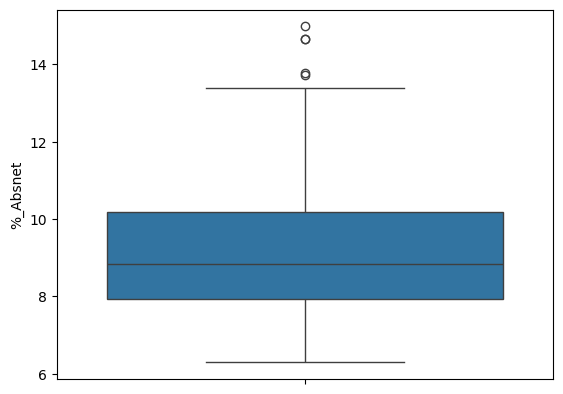

In [ ]:
sns.boxplot(y = '%_Absnet', data = df_mean)
plt.show()

In [ ]:
df_mean['y']=df_mean['%_Absnet']
df_mean['ds']=df_mean['Date']
df_mean.head()

,Date,%_Absnet,y,ds
1,2018-09-05,12.358143,12.358143,2018-09-05
2,2018-09-06,10.566173,10.566173,2018-09-06
3,2018-09-07,10.819386,10.819386,2018-09-07
4,2018-09-12,7.298906,7.298906,2018-09-12
5,2018-09-13,7.227160,7.227160,2018-09-13


In [ ]:
# Let's plot the average of %_Absnet for all schools.
from plotly.express import line
col = ['%_Absnet']
line(data_frame=df_mean, x='Date', y=col)

In [ ]:
from plotly.express import scatter
scatter(data_frame=df_mean, x='Date', y=col, trendline='ols', trendline_scope='overall').show()
scatter(data_frame=df_mean, x='Date', y=col, trendline='lowess', trendline_scope='overall').show()

<div class="alert alert-block alert-info" style="background-color:#CDFCDC;color:#0FD34D;border-color:black;width:80%;margin: auto;text-align: center;"><b>Comment:</b> We can see that there is an increase in the %_Absnet over time.</div>

In [ ]:
train_df=df_mean[(df_mean['ds']>'2018-09-04') & (df_mean['ds']<'2019-05-01')]
test_df=df_mean[df_mean['ds']>='2019-05-01']

In [ ]:
train_df

,Date,%_Absnet,y,ds
1,2018-09-05,12.358143,12.358143,2018-09-05
2,2018-09-06,10.566173,10.566173,2018-09-06
3,2018-09-07,10.819386,10.819386,2018-09-07
4,2018-09-12,7.298906,7.298906,2018-09-12
5,2018-09-13,7.227160,7.227160,2018-09-13
...,...,...,...,...
141,2019-04-16,8.390943,8.390943,2019-04-16
142,2019-04-17,9.113177,9.113177,2019-04-17
143,2019-04-18,12.930614,12.930614,2019-04-18
144,2019-04-29,11.055911,11.055911,2019-04-29


In [ ]:
test_df

,Date,%_Absnet,y,ds,Month
146,2019-05-01,7.645633,7.645633,2019-05-01,2019-05-01
147,2019-05-02,7.739228,7.739228,2019-05-02,2019-05-02
148,2019-05-03,11.435576,11.435576,2019-05-03,2019-05-03
149,2019-05-06,9.582551,9.582551,2019-05-06,2019-05-06
150,2019-05-07,8.901816,8.901816,2019-05-07,2019-05-07
151,2019-05-08,8.907291,8.907291,2019-05-08,2019-05-08
152,2019-05-09,8.882342,8.882342,2019-05-09,2019-05-09
153,2019-05-10,11.698535,11.698535,2019-05-10,2019-05-10
154,2019-05-13,11.882414,11.882414,2019-05-13,2019-05-13
155,2019-05-14,9.372418,9.372418,2019-05-14,2019-05-14


In [ ]:
print('Shape of train data',train_df.shape)
print('Shape of test data',test_df.shape)

Shape of train data (136, 4)
Shape of test data (31, 5)


In [ ]:
model= Prophet()
model.fit(train_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=50)
future

,ds
0,2018-09-05
1,2018-09-06
2,2018-09-07
3,2018-09-12
4,2018-09-13
...,...
181,2019-06-15
182,2019-06-16
183,2019-06-17
184,2019-06-18


In [ ]:
# future = future.merge(test_df, on='ds', how='left')
# future.bfill(inplace = True)
# future

,ds,Date,%_Absnet,y,Month
0,2018-09-05,2019-05-01,7.645633,7.645633,2019-05-01
1,2018-09-06,2019-05-01,7.645633,7.645633,2019-05-01
2,2018-09-07,2019-05-01,7.645633,7.645633,2019-05-01
3,2018-09-12,2019-05-01,7.645633,7.645633,2019-05-01
4,2018-09-13,2019-05-01,7.645633,7.645633,2019-05-01
...,...,...,...,...,...
188,2019-06-22,NaT,NaN,NaN,NaT
189,2019-06-23,NaT,NaN,NaN,NaT
190,2019-06-24,NaT,NaN,NaN,NaT
191,2019-06-25,NaT,NaN,NaN,NaT


In [ ]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-09-05,8.719783,5.585143,9.267997,8.719783,8.719783,-1.251715,-1.251715,-1.251715,-1.251715,-1.251715,-1.251715,0.0,0.0,0.0,7.468069
1,2018-09-06,8.727407,5.800793,9.623538,8.727407,8.727407,-1.021364,-1.021364,-1.021364,-1.021364,-1.021364,-1.021364,0.0,0.0,0.0,7.706042
2,2018-09-07,8.735031,7.211643,11.035757,8.735031,8.735031,0.489646,0.489646,0.489646,0.489646,0.489646,0.489646,0.0,0.0,0.0,9.224676
3,2018-09-12,8.773149,5.672892,9.373370,8.773149,8.773149,-1.251715,-1.251715,-1.251715,-1.251715,-1.251715,-1.251715,0.0,0.0,0.0,7.521435
4,2018-09-13,8.780773,5.831951,9.700407,8.780773,8.780773,-1.021364,-1.021364,-1.021364,-1.021364,-1.021364,-1.021364,0.0,0.0,0.0,7.759408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,2019-06-15,10.943524,10.850798,14.566050,10.942526,10.944533,1.810475,1.810475,1.810475,1.810475,1.810475,1.810475,0.0,0.0,0.0,12.753999
182,2019-06-16,10.951406,10.972446,14.700938,10.950380,10.952448,1.810475,1.810475,1.810475,1.810475,1.810475,1.810475,0.0,0.0,0.0,12.761882
183,2019-06-17,10.959289,8.332799,12.055947,10.958210,10.960375,-0.751936,-0.751936,-0.751936,-0.751936,-0.751936,-0.751936,0.0,0.0,0.0,10.207352
184,2019-06-18,10.967172,7.938670,11.748593,10.966049,10.968286,-1.085581,-1.085581,-1.085581,-1.085581,-1.085581,-1.085581,0.0,0.0,0.0,9.881590


In [ ]:
test_df.shape

(31, 5)

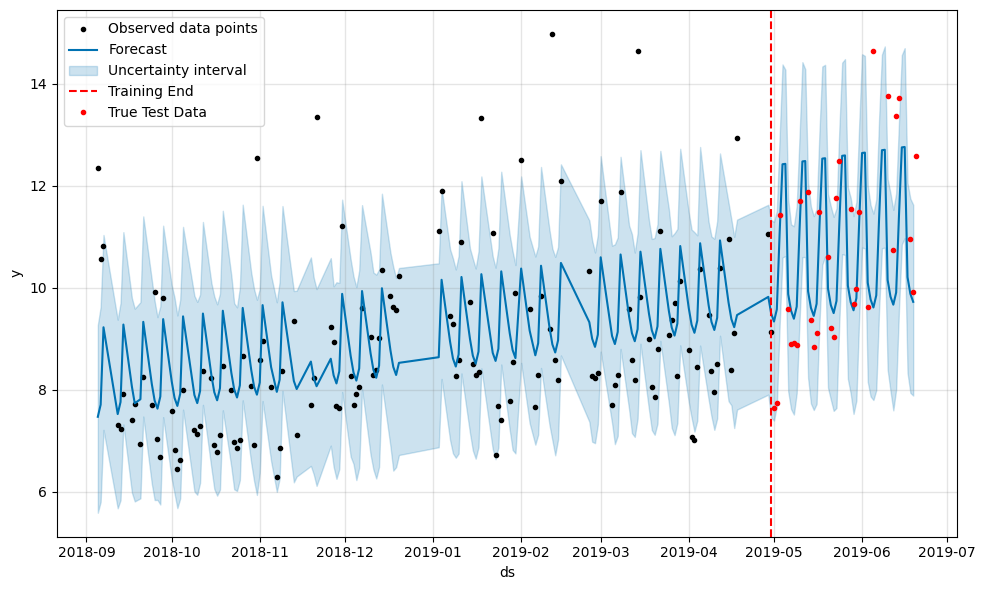

In [ ]:
# plot the time series
forecast_plot = model.plot(forecast)
# add a vertical line at the end of the training period
axes = forecast_plot.gca()
last_training_date = forecast['ds'].iloc[-51]
axes.axvline(x=last_training_date, color='red', linestyle='--', label='Training End')

# plot true test data for the period after the red line
test_df['Month'] = pd.to_datetime(test_df['ds'])
plt.plot(test_df['Month'], test_df['y'],'ro', markersize=3, label='True Test Data')

# show the legend to distinguish between the lines
plt.legend()

<div class="alert alert-block alert-info" style="background-color:#CDFCDC;color:#0FD34D;border-color:black;width:80%;margin: auto;text-align: center;"><b>Comment:</b>  Here we can see that even with the exclusion of outliers there are values ​that fall outside the Uncertainty Interval."</div>

#MLFLOW

In [ ]:
%pip install -q dagshub 'mlflow>=2,<3'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.3/261.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
import dagshub
dagshub.init(repo_owner='MarcosEduardoGarcia', repo_name='my-first-repo', mlflow=True)

Initialized MLflow to track repo "MarcosEduardoGarcia/my-first-repo"

Repository MarcosEduardoGarcia/my-first-repo initialized!

In [ ]:
import mlflow
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = Prophet()
model.fit(train_df)

# Realizar predicciones
forecast = model.predict(future)

# Hacer merge y eliminar filas sin predicción
merged = test_df.merge(forecast[['ds', 'yhat']], on='ds', how='left')
merged = merged.dropna(subset=['yhat'])

# Extraer valores
y_true = merged['y'].values
y_pred = merged['yhat'].values

print(len(y_true), len(y_pred))  # Ahora deben coincidir

# Calcular métricas
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


30 30
MAE: 1.1511965404400633
RMSE: 1.6402945242698899


In [ ]:
# ======================================
# 🔹 SUBIR MODELO A DAGSHUB USANDO MLFLOW
# ======================================

import mlflow
import mlflow.pyfunc
import mlflow.prophet

# Iniciar sesión con DagsHub (ya lo tienes configurado arriba)
#dagshub.init(repo_owner='MarcosEduardoGarcia', repo_name='my-first-repo', mlflow=True)


# Iniciar un nuevo run
with mlflow.start_run(run_name="prophet_model_v1"):
    model = Prophet()
    model.fit(train_df)

    # Realizar predicciones
    forecast = model.predict(future)

    # Hacer merge y eliminar filas sin predicción
    merged = test_df.merge(forecast[['ds', 'yhat']], on='ds', how='left')
    merged = merged.dropna(subset=['yhat'])

    # Extraer valores
    y_true = merged['y'].values
    y_pred = merged['yhat'].values

    print(len(y_true), len(y_pred))  # Ahora deben coincidir

    # Calcular métricas
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Registrar métricas
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)

    # Registrar parámetros del modelo
    mlflow.log_param("growth", model.growth)
    mlflow.log_param("seasonality_mode", model.seasonality_mode)
    mlflow.log_param("changepoint_prior_scale", model.changepoint_prior_scale)


    print("✅ Modelo registrado correctamente en MLflow (DagsHub).")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")

Initialized MLflow to track repo "MarcosEduardoGarcia/my-first-repo"

Repository MarcosEduardoGarcia/my-first-repo initialized!

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


30 30
MAE: 1.1511965404400633
RMSE: 1.6402945242698899
✅ Modelo registrado correctamente en MLflow (DagsHub).
MAE: 1.1512 | RMSE: 1.6403
🏃 View run prophet_model_v1 at: https://dagshub.com/MarcosEduardoGarcia/my-first-repo.mlflow/#/experiments/1/runs/c5bab878c5774541bf800ccdc681b7e2
🧪 View experiment at: https://dagshub.com/MarcosEduardoGarcia/my-first-repo.mlflow/#/experiments/1


✅ Modelo y plot registrados correctamente en MLflow (DagsHub).
MAE: 3.6422 | RMSE: 4.0188
🏃 View run prophet_model_v2 at: https://dagshub.com/MarcosEduardoGarcia/my-first-repo.mlflow/#/experiments/1/runs/c23f2b5216284d62812d029a683164da
🧪 View experiment at: https://dagshub.com/MarcosEduardoGarcia/my-first-repo.mlflow/#/experiments/1


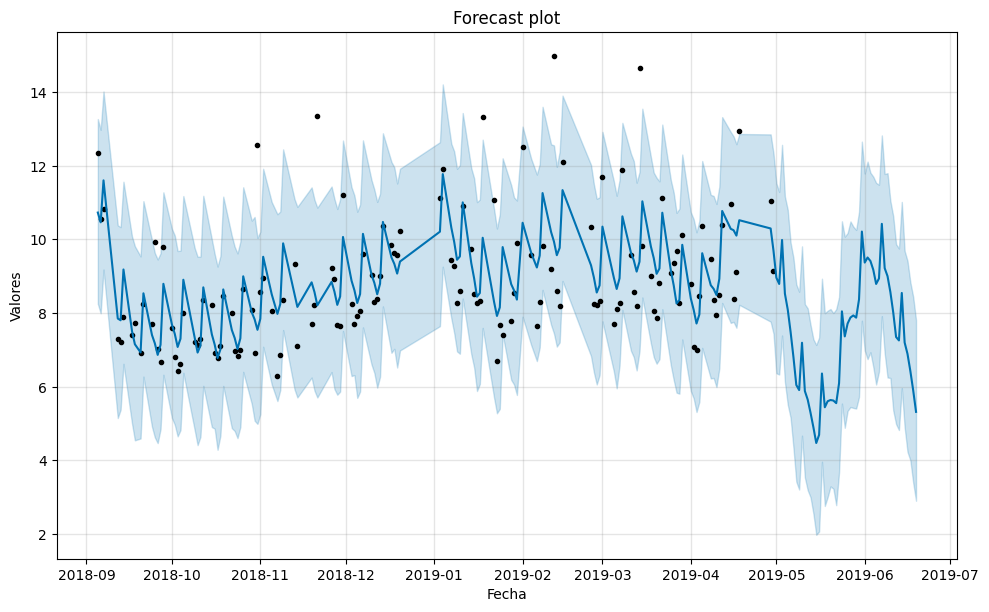

In [ ]:
import mlflow
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --- Definir parámetros ajustables ---
params = {
    "growth": "linear",
    "changepoint_prior_scale": 0.05,
    "seasonality_mode": "additive",
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "daily_seasonality": True,
    "weekly_seasonality": True,
    "yearly_seasonality": True,
    "interval_width": 0.95,
    "mcmc_samples": 0
}

with mlflow.start_run(run_name="prophet_model_v2"):

    # Crear modelo
    model = Prophet(
        growth=params["growth"],
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        holidays_prior_scale=params["holidays_prior_scale"],
        daily_seasonality=params["daily_seasonality"],
        weekly_seasonality=params["weekly_seasonality"],
        yearly_seasonality=params["yearly_seasonality"],
        interval_width=params["interval_width"],
        mcmc_samples=params["mcmc_samples"]
    )

    # Entrenar modelo
    model.fit(train_df)

    # Predicciones
    forecast = model.predict(future)

    # Merge con test
    merged = test_df.merge(forecast[['ds', 'yhat']], on='ds', how='left').dropna(subset=['yhat'])
    y_true = merged['y'].values
    y_pred = merged['yhat'].values

    # Métricas
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)

    # Registrar parámetros
    for key, value in params.items():
        mlflow.log_param(key, value)

    # --- Crear plot ---
    fig = model.plot(forecast)
    plt.title("Forecast plot")
    plt.xlabel("Fecha")
    plt.ylabel("Valores")

    # Guardar plot como imagen y subirlo a MLflow
    plot_path = "prophet_forecast.png"
    fig.savefig(plot_path)
    mlflow.log_artifact(plot_path)

    print("✅ Modelo y plot registrados correctamente en MLflow (DagsHub).")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
